In [618]:
from typing import Callable

import numpy as np
import sympy as sp
import mpmath as mp
import matplotlib.pyplot as plt

In [619]:
x = sp.symbols('x')

In [620]:
F1_DOMAIN = [(3/2) * np.pi, 2 * np.pi]

f1_sym = sp.cos(x) * sp.cosh(x) - 1
f1_deriv_sym = sp.Derivative(f1_sym, evaluate=True)

f1 = sp.lambdify(x, f1_sym, modules='mpmath')
f1_deriv = sp.lambdify(x, f1_deriv_sym, modules='mpmath')

In [621]:
F2_DOMAIN = [0.0001, np.pi / 2]

f2_sym = (1 / x) - sp.tan(x)
f2_deriv_sym = sp.Derivative(f2_sym, evaluate=True)

f2 = sp.lambdify(x, f2_sym, modules='mpmath')
f2_deriv = sp.lambdify(x, f2_deriv_sym, modules='mpmath') 

In [622]:
F3_DOMAIN = [1, 3]

f3_sym = 2 ** (-x) + sp.exp(x) + 2 * sp.cos(x) - 6
f3_deriv_sym = sp.Derivative(f3_sym, evaluate=True)

f3 = sp.lambdify(x, f3_sym, modules='mpmath')
f3_deriv = sp.lambdify(x, f3_deriv_sym, modules='mpmath')

In [623]:
display(f1_sym)
display(f1_deriv_sym)

cos(x)*cosh(x) - 1

-sin(x)*cosh(x) + cos(x)*sinh(x)

$
a + \frac{b - a}{2}
$

$
|f(c)| < \epsilon 
$

$
|b - a| < \delta
$

In [624]:
display(f2_sym)
display(f2_deriv_sym)

-tan(x) + 1/x

-tan(x)**2 - 1 - 1/x**2

In [625]:
display(f3_sym)
display(f3_deriv_sym)

exp(x) + 2*cos(x) - 6 + 2**(-x)

exp(x) - 2*sin(x) - log(2)/2**x

In [626]:
def plot_function(f_symbolic, f: Callable, domain: tuple[float, float], ax: plt.Axes | None = None, solution: tuple[float, float] | None = None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    X = np.arange(*domain, 0.001)

    ax.grid()           
    ax.axhline(color='k')
    ax.axvline(color='k')
    ax.set_xlim(domain[0] - 0.1, domain[1] + 0.01)
    ax.set_ylim(-20, 20)
    ax.set_title(f"${sp.latex(f_symbolic)}$")

    if solution:
        ax.scatter([solution], [0], color='r')

    ax.plot(X, [f(x) for x in X])

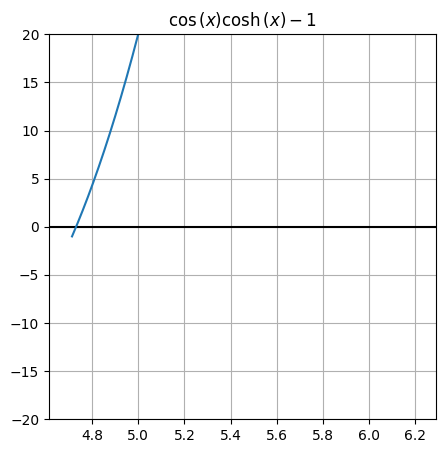

In [627]:
plot_function(f1_sym, f1, F1_DOMAIN)


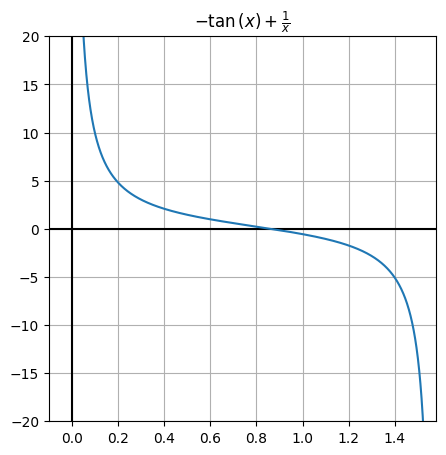

In [628]:
plot_function(f2_sym, f2, F2_DOMAIN)


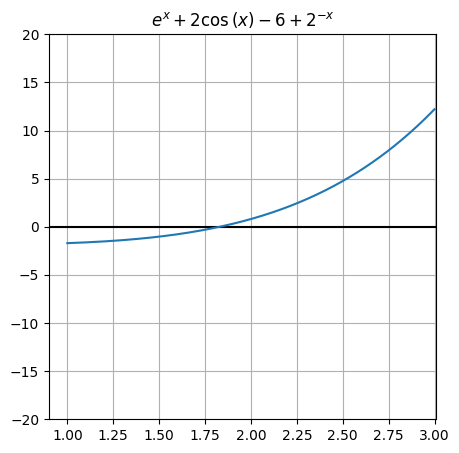

In [629]:
plot_function(f3_sym, f3, F3_DOMAIN)


In [630]:
def bisect(f: Callable, domain: tuple[float, float], precision: int=15, eps: float=10**-8) -> tuple[float, int]:
    a, b = domain
    n = int(np.ceil(np.log((b - a) / eps) / np.log(2)))

    with mp.workdps(precision):
        for _ in range(n):
            c = a + (b - a) / 2

            if f(a) * f(c) < 0:
                b = c
            else:
                a = c

    return c, n


iters=28, val=-1.05398501704101e-07


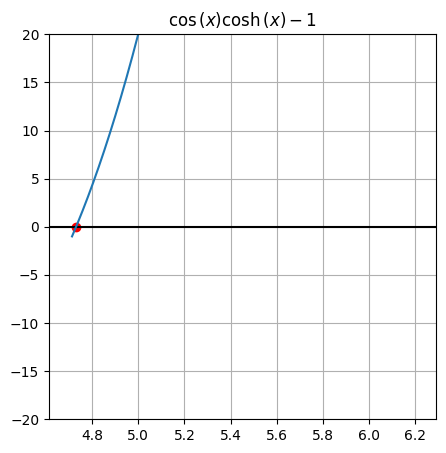

In [631]:
s, n = bisect(f1, F1_DOMAIN)
print(f"iters={n}, val={f1(s)}")
plot_function(f1_sym, f1, domain=F1_DOMAIN, solution=s)

iters=28, val=1.953480666117e-08


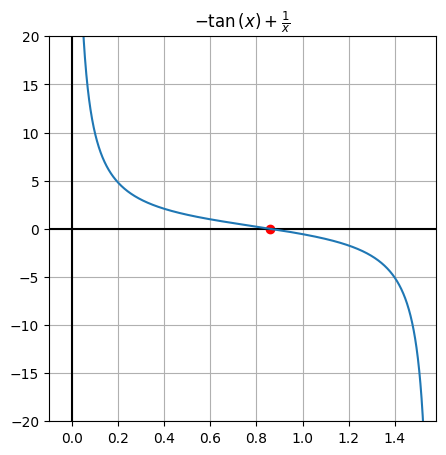

In [632]:
s, n = bisect(f2, F2_DOMAIN)
print(f"iters={n}, val={f2(s)}")
plot_function(f2_sym, f2, domain=F2_DOMAIN, solution=s)

iters=28, val=9.41149785882445e-09


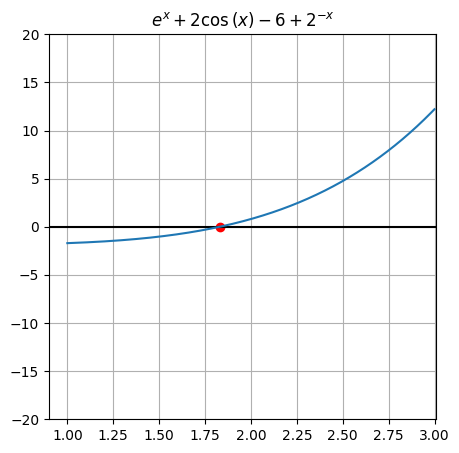

In [633]:
s, n = bisect(f3, F3_DOMAIN)
print(f"iters={n}, val={f3(s)}")
plot_function(f3_sym, f3, domain=F3_DOMAIN, solution=s)

Wady:
Trzeba wybrać punkt początkowy
Nie zawsze zbiega

Zalety:
Zbiega kwadratowo

In [634]:
def newton(f: Callable, f_deriv: Callable, domain: tuple[float, float], max_iters: int = 10 ** 5, min_step: float = 10 ** -8, precision: int = 15):
    print(f"used_precision={precision}")
    print(f"max_iters={max_iters}")
    print(f"min_step={min_step}")

    x = domain[0]
    i = 0

    with mp.workdps(precision):
        while i < max_iters:
            x_next = x - f(x) / f_deriv(x)

            # If our step got too small, stop
            if np.abs(x_next - x) < min_step:
                break

            i += 1
            x = x_next

    return x, i

used_precision=15
max_iters=100000
min_step=1e-08
iters=3, val=5.48006084954977e-13


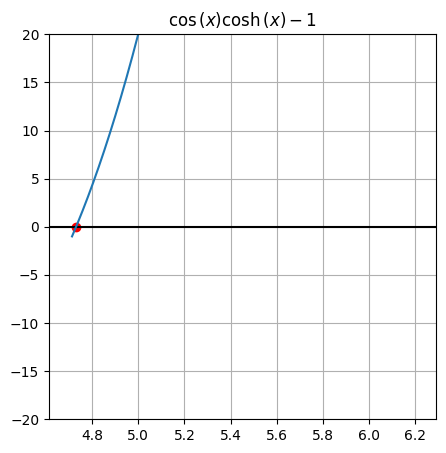

In [635]:
s, n = newton(f1, f1_deriv, F1_DOMAIN)
print(f"iters={n}, val={f1(s)}")
plot_function(f1_sym, f1, domain=F1_DOMAIN, solution=s)

used_precision=15
max_iters=100000
min_step=1e-08
iters=16, val=-8.1280027153241e-10


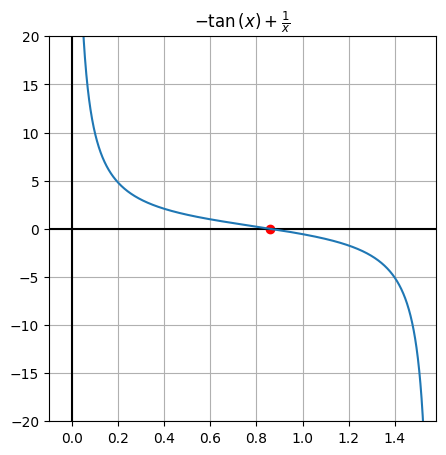

In [636]:
s, n = newton(f2, f2_deriv, F2_DOMAIN)
print(f"iters={n}, val={f2(s)}")
plot_function(f2_sym, f2, domain=F2_DOMAIN, solution=s)

used_precision=15
max_iters=100000
min_step=1e-08
iters=7, val=-1.78085642446155


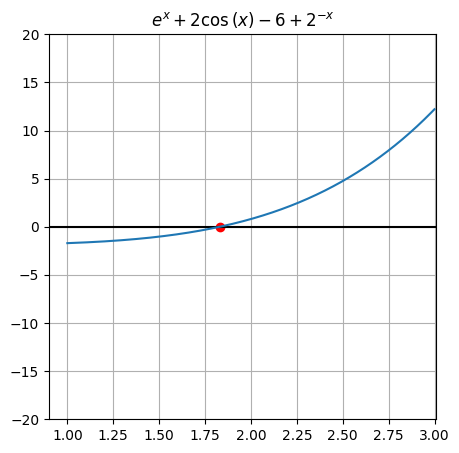

In [637]:
s3_newton, n = newton(f3, f3_deriv, F3_DOMAIN)
print(f"iters={n}, val={f3(s)}")
plot_function(f3_sym, f3, domain=F3_DOMAIN, solution=s3_newton)

In [638]:
def secands(f: Callable, domain: tuple[float, float], max_iters: int = 10 ** 5, min_step: float = 10 ** -8, precision: int = 15):
    print(f"used_precision={precision}")
    print(f"max_iters={max_iters}")
    print(f"min_step={min_step}")

    x = domain[0]
    x_prev = x + ((domain[1] - domain[0]) / 5)
    i = 0

    with mp.workdps(precision):
        while i < max_iters:
            deriv_inv = ((x - x_prev)/(f(x) - f(x_prev)))
            x_next = x - deriv_inv * f(x)

            # If our step got too small, stop
            if np.abs(x_next - x) < min_step:
                break

            i += 1
            x_prev = x
            x = x_next

    return x, i

Metoda hybdyrowa.

Kilka iteracji metodą bisekcji, a potem zbiegamy metodą stycznych

used_precision=15
max_iters=100000
min_step=1e-08
iters=4, val=-1.38419387063493e-09


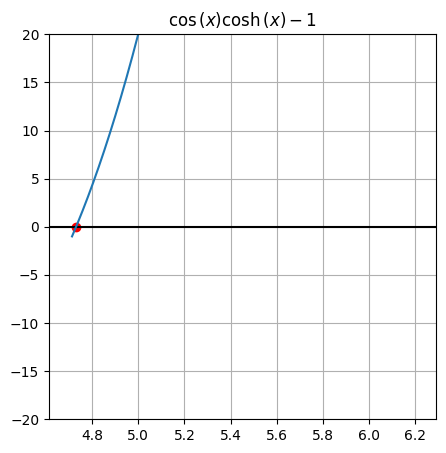

In [639]:
s, n = secands(f1, F1_DOMAIN)
print(f"iters={n}, val={f1(s)}")
plot_function(f1_sym, f1, domain=F1_DOMAIN, solution=s)

used_precision=15
max_iters=100000
min_step=1e-08
iters=8, val=9.16282605345486e-11


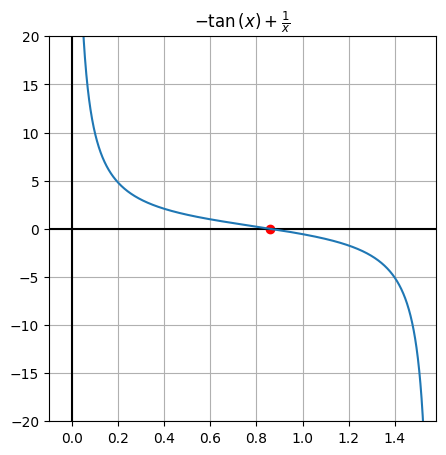

In [640]:
s, n = secands(f2, F2_DOMAIN)
print(f"iters={n}, val={f2(s)}")
plot_function(f2_sym, f2, domain=F2_DOMAIN, solution=s)

used_precision=15
max_iters=100000
min_step=1e-08
iters=8, val=-1.7808564245754


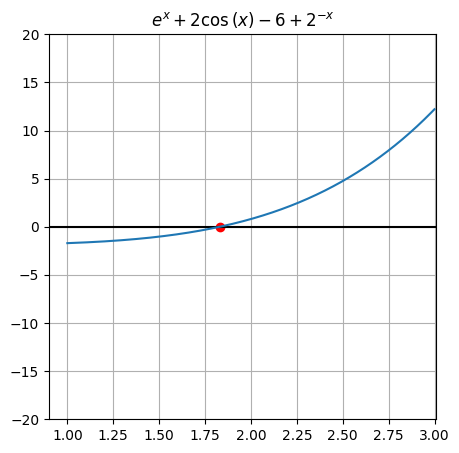

In [641]:
s3_secands, n = secands(f3, F3_DOMAIN)
print(f"iters={n}, val={f3(s)}")
plot_function(f3_sym, f3, domain=F3_DOMAIN, solution=s3_secands)

In [642]:
def hybrid(
        f: Callable, 
        domain: tuple[float, float], 
        bisect_iters: int = 5, 
        precision: int = 15, 
        max_iters: int = 10**4, 
        min_step: float = 10 ** -8
) -> tuple[float, int]:
    with mp.workdps(precision):
        a, b = domain

        for _ in range(bisect_iters):
            c = a + (b - a) / 2

            if np.sign(f(a)) != np.sign(f(c)):
                b = c
            else:
                a = c

        i = 0

        x = a
        x_prev = b

        while i < max_iters:
            deriv_inv = ((x - x_prev)/(f(x) - f(x_prev)))
            x_next = x - deriv_inv * f(x)

            # If our step got too small, stop
            if np.abs(x_next - x) < min_step:
                break

            i += 1
            x_prev = x
            x = x_next

        return x, i + bisect_iters

iters=8, val=-2.90182283535501e-07


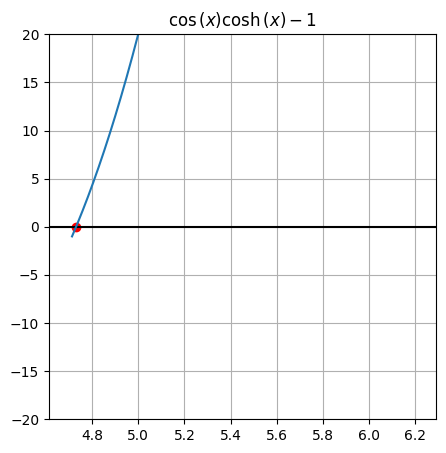

In [643]:
s, n = hybrid(f1, F1_DOMAIN)
print(f"iters={n}, val={f1(s)}")
plot_function(f1_sym, f1, domain=F1_DOMAIN, solution=s)

iters=8, val=2.87686541255994e-10


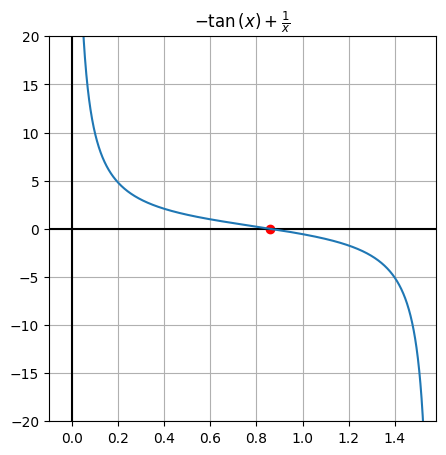

In [644]:
s, n = hybrid(f2, F2_DOMAIN)
print(f"iters={n}, val={f2(s)}")
plot_function(f2_sym, f2, domain=F2_DOMAIN, solution=s)

iters=8, val=-1.78085642460008


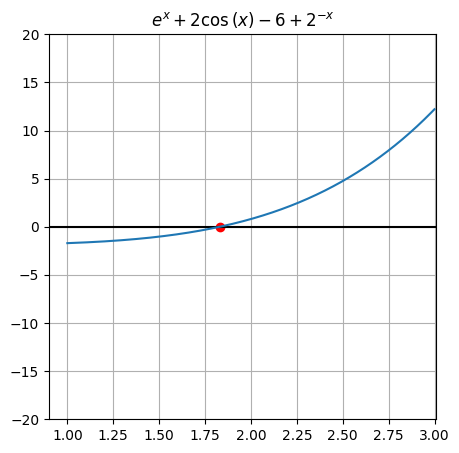

In [645]:
s3_hybrid, n = hybrid(f3, F3_DOMAIN)
print(f"iters={n}, val={f3(s)}")
plot_function(f3_sym, f3, domain=F3_DOMAIN, solution=s3_hybrid)

In [ ]:
np.abs(s3_hybrid) < np.abs(s3_newton)

True

In [647]:
np.abs(s3_hybrid) < np.abs(s3_secands)

False